[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-3/time-travel.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239536-lesson-5-time-travel)

# Time travel

## 回顧

我們討論過導入 human-in-the-loop 的幾個動機：

(1) `Approval`（核准）—— 我們可以中斷 agent、把 state 呈現給使用者，並讓使用者決定是否接受某個動作

(2) `Debugging`（除錯）—— 我們可以把 graph 倒帶，以重現或避開問題

(3) `Editing`（編輯）—— 你可以修改 state 

我們示範了 breakpoint 如何讓 graph 停在特定 node，或讓 graph 自行動態中斷。

接著我們展示了如何在取得人類核准後繼續執行，或直接用人類回饋編輯 graph state。

## 目標

現在，我們來示範 LangGraph 如何[支援除錯](https://docs.langchain.com/oss/python/langgraph/use-time-travel)：透過檢視、重播（re-play），甚至從過去的 state 分岔（fork）出去。

我們把這個能力稱為 `time travel`。

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langgraph_sdk langgraph-prebuilt

In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

我們先來建立 agent。

In [2]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """將 a 與 b 相乘。

    Args:
        a: 第一個整數
        b: 第二個整數
    """
    return a * b

# 這會是一個 tool
def add(a: int, b: int) -> int:
    """將 a 與 b 相加。

    Args:
        a: 第一個整數
        b: 第二個整數
    """
    return a + b

def divide(a: int, b: int) -> float:
    """將 a 除以 b。

    Args:
        a: 第一個整數
        b: 第二個整數
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm.bind_tools(tools)

/Users/kevinluo/langgraph-deepagents-book-make/.venv/lib/python3.12/site-packages/pyppeteer/us_keyboard_layout.py:73: SyntaxWarning: invalid escape sequence '\('
  'Digit9': {'keyCode': 57, 'code': 'Digit9', 'shiftKey': '\(', 'key': '9'},
/Users/kevinluo/langgraph-deepagents-book-make/.venv/lib/python3.12/site-packages/pyppeteer/us_keyboard_layout.py:143: SyntaxWarning: invalid escape sequence '\<'
  'Comma': {'keyCode': 188, 'code': 'Comma', 'shiftKey': '\<', 'key': ','},
/Users/kevinluo/langgraph-deepagents-book-make/.venv/lib/python3.12/site-packages/pyppeteer/us_keyboard_layout.py:247: SyntaxWarning: invalid escape sequence '\<'
  '<': {'keyCode': 188, 'key': '\<', 'code': 'Comma'},


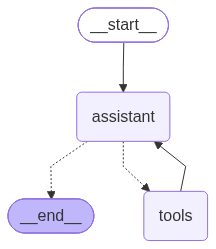

In [3]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# 系統 message：每次呼叫 LLM 時都墊在 messages 最前面（見下面的 assistant node）。
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# assistant node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# 組 graph
builder = StateGraph(MessagesState)

# 定義 node：這些 node 負責實際工作
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# 定義 edge：這些 edge 決定控制流程
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # 如果 assistant 最新的 message（結果）是一個 tool call -> tools_condition 會 route 到 tools
    # 如果 assistant 最新的 message（結果）不是 tool call -> tools_condition 會 route 到 END
    tools_condition,
)
builder.add_edge("tools", "assistant")

# ⚠️ 原始教材的瑕疵：這行建好的 memory 從頭到尾沒有人用到——下一行 compile 時又 new 了
#    一顆全新的 MemorySaver。兩顆是各自獨立的記憶體，本章實際用的是 compile 裡那顆。
#    執行結果完全不受影響，所以不改它；但學員如果盯著 memory 找它在哪被使用，會找到懷疑人生。
#    講的時候直接說：這行是教材寫剩的，當它不存在。
memory = MemorySaver()

# checkpointer 是這一整章的地基。
# 沒有它：graph 跑完就什麼都不留，也就沒有「過去」可以回去，time travel 無從談起。
# 有了它：每跑完一個 node 就存一格檔（checkpoint），整個 thread 串成一條時間線。
# 本章做的事情就只有一件——在這些存檔之間跳。
#
# MemorySaver = 存在 RAM 裡，kernel 一重啟就全沒了。正式環境會換成 SqliteSaver / PostgresSaver，
# 但 API 完全一樣，所以這章學到的東西原封不動可以搬過去。
graph = builder.compile(checkpointer=MemorySaver())

# 顯示
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

如同先前一樣，我們來執行它。

In [4]:
# 輸入
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# thread_id = 這次對話的「存檔名稱」。這一跑留下的所有 checkpoint 都掛在 thread "1" 底下，
# 串成一條時間線。本章後面的 replay 和 fork，全部都是回頭翻這條時間線上的存檔。
thread = {"configurable": {"thread_id": "1"}}

# ⚠️ 原始教材的瑕疵：這裡原本的註解寫「執行 graph，直到第一次 interruption」，是從上一章
#    breakpoints 複製過來忘了改。這個 graph 在 compile 時並沒有設 interrupt_before，
#    不會停在任何地方，會一路跑到底——看輸出就知道，四則 message 全部跑完了。
#
# 這一跑的重點不是它算出 6，而是它沿路留下的那串存檔。
# 得先有歷史，下面才有東西可以回去。
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_FHJyHsPxzUNdcu1y6DCEG016)
 Call ID: call_FHJyHsPxzUNdcu1y6DCEG016
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


## Browsing History

我們可以用 `get_state` 來查看 graph 在某個 `thread_id` 下的**目前**state！

In [5]:
# get_state = 「這個存檔現在停在哪一格？」只給 thread_id，拿到的永遠是**最新**那一格。
#
# 印出來的 StateSnapshot 有三個欄位要盯著看：
#   values → 這一格當下的 state 內容。這裡是完整四則：human 提問 → AI 發 tool call → tool 回 6 → AI 講答案。
#   next   → 從這格恢復的話，下一站要跑哪個 node。這裡是空的 ()，代表這條線已經跑到終點了。
#   config → 裡面藏著 checkpoint_id（1ef6a440-a003-...），**這是本章的鑰匙**：
#            每一格存檔的唯一身分證。認得它，就能對 graph 指名「我要回到那一格」。
#            整章的 time travel 說穿了就是在玩這個 id，其他都是配角。
graph.get_state({'configurable': {'thread_id': '1'}})

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='35819edd-75d6-4d98-ab20-d7b882d14b7b'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 154, 'total_tokens': 171, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_64d0f9e03c', 'id': 'chatcmpl-E7FwP1CVlw4eQ2p0G45DOhZ7w08cj', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fb207-b63d-72f2-9c1f-1a46fcd0dde9-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_FHJyHsPxzUNdcu1y6DCEG016', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 154, 'output

我們也可以瀏覽 agent 的 state 歷史紀錄。

`get_state_history` 讓我們取得先前每一個步驟的 state。


In [7]:
# get_state_history = 把這個 thread 的所有存檔一格一格倒出來。
#
# ⚠️ 踩雷（本章最大的坑，整章看不懂十之八九是卡在這）：它是**反時序**的，最新在前、最舊在後。
#    像滑聊天記錄往上翻，不是像日記從第一頁讀起。所以：
#      all_states[0]  → 最新：已經跑完的最終 state
#      all_states[-1] → 最舊：graph 還沒動半個 node 的空狀態
#      all_states[-2] → 倒數第二舊：只有 human message、assistant 還沒跑的那一刻
#                       ← 本章後面 replay 和 fork 要回去的，就是這一格
#    如果誤以為它是正序，底下每一個 [-2] 都會像是隨便亂挑的數字。這點一定要先講死。
all_states = [s for s in graph.get_state_history(thread)]
all_states

[StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='35819edd-75d6-4d98-ab20-d7b882d14b7b'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 154, 'total_tokens': 171, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_64d0f9e03c', 'id': 'chatcmpl-E7FwP1CVlw4eQ2p0G45DOhZ7w08cj', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fb207-b63d-72f2-9c1f-1a46fcd0dde9-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_FHJyHsPxzUNdcu1y6DCEG016', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 154, 'outpu

In [8]:
# 5 格存檔。對照上面那一跑，由舊到新分別是：
#   空狀態 → 收到 human message → assistant 發出 tool call → tools 算出 6 → assistant 講出答案
#
# 也就是「每跑完一個 node 存一格」，不是「整跑存一格」。
# node 跑得越多，可以回去的點就越多——這也是為什麼 time travel 在 agent 上特別有用：
# agent 每一步都是一個可以回去重來的路口。
len(all_states)

5

第一個元素就是目前的 state，跟我們用 `get_state` 取得的一樣。

In [9]:
# 為什麼挑 [-2]，不挑 [0]？
# 因為我們要回到「事情還沒發生的那一刻」——human 剛講完話、assistant 還沒開口。
# [0] 是已經跑完的結局，回去也沒東西可跑（它的 next 是空的）。
#
# ⚠️ 原始教材的瑕疵：上一段 markdown 寫「第一個元素就是目前的 state」，講的是 all_states[0]，
#    但這格印的卻是 all_states[-2]，文跟碼對不起來。講的時候直接跳過那句，
#    改講：我們略過 [0]，直接看 [-2]，因為它才是等一下要回去的那格。
all_states[-2]

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='35819edd-75d6-4d98-ab20-d7b882d14b7b')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18bec6-0bfe-6e1c-8000-5673a10d4ec4'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-30T07:57:57.692972+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18bec6-0bfc-659a-bfff-f50dda88a8a2'}}, tasks=(PregelTask(id='eb1c9e19-232b-ded8-8c07-c10c62a6f47b', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 154, 'total_tokens': 171, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_predi

上面所有內容都可以用下圖來視覺化呈現：

![fig1.jpg](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb038211b544898570be3_time-travel1.png)

## Replaying 

我們可以從先前任何一個步驟重新執行 agent。

![fig2.jpg](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb038a0bd34b541c78fb8_time-travel2.png)

我們來回頭看接收到人類輸入的那個步驟！

In [12]:
all_states

[StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='35819edd-75d6-4d98-ab20-d7b882d14b7b'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 154, 'total_tokens': 171, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_64d0f9e03c', 'id': 'chatcmpl-E7FwP1CVlw4eQ2p0G45DOhZ7w08cj', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fb207-b63d-72f2-9c1f-1a46fcd0dde9-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_FHJyHsPxzUNdcu1y6DCEG016', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 154, 'outpu

In [10]:
# 挑一格存檔，當作「等一下要回去的目標」。
# 挑 [-2] 的理由只有一個：它的 next 是 ('assistant',)，回去之後**還有東西可以跑**。
# 反例：挑 [0]（最終 state）的話 next=()，回去等於什麼都不會發生，示範不出任何效果。
to_replay = all_states[-2]

In [11]:
# 接下來連續四格（to_replay / .values / .next / .config）在做同一件事：
# **開存檔之前先確認我挑中的這格對不對**。這是給眼睛看的健康檢查，程式邏輯完全不需要這幾行。
# 為什麼要一格一格看？因為挑錯 checkpoint 不會報錯，只會安靜地跑出你看不懂的結果——
# 事前多看兩眼，比事後 debug 便宜。
# 這格先看全貌，下面三格再一個欄位一個欄位拆開驗。
to_replay

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='35819edd-75d6-4d98-ab20-d7b882d14b7b')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18bec6-0bfe-6e1c-8000-5673a10d4ec4'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-30T07:57:57.692972+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18bec6-0bfc-659a-bfff-f50dda88a8a2'}}, tasks=(PregelTask(id='eb1c9e19-232b-ded8-8c07-c10c62a6f47b', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 154, 'total_tokens': 171, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_predi

看看這個 state。

In [10]:
# 檢查點一：values —— 這格存檔當下的 state 長什麼樣。
# 輸出只有一則 HumanMessage「Multiply 2 and 3」，沒有 AIMessage、沒有 ToolMessage。
# 這就是鐵證：在這一刻，assistant 確實還沒開口。挑對了。
to_replay.values

{'messages': [HumanMessage(content='Multiply 2 and 3', id='4ee8c440-0e4a-47d7-852f-06e2a6c4f84d')]}

我們可以看到接下來要呼叫的 node。

In [11]:
# 檢查點二：next —— 「從這格恢復的話，下一站是誰？」
# ('assistant',) 代表恢復之後 graph 會先跑 assistant node，也就是「LLM 即將第一次看到這個問題」。
# 對照組：如果這裡是空的 ()，代表這格是終點，回去也不會跑任何東西——看到 () 就是挑錯格了。
to_replay.next

('assistant',)

我們也會拿到 config，它會告訴我們 `checkpoint_id` 以及 `thread_id`。

In [13]:
# 檢查點三：config —— **time travel 的機關全部在這一格裡**，這頁只要記住下面這組對照。
#
#   平常用的 thread   = {'configurable': {'thread_id': '1'}}
#                       → 只有 thread_id，意思是「從**最新**那格繼續」
#   to_replay.config = {'configurable': {'thread_id': '1', 'checkpoint_id': '1ef6a440-a003-...'}}
#                       → 多了 checkpoint_id，意思是「從**指定的那一格**繼續」
#
# 差別就只有多一個 checkpoint_id 而已。
# LangGraph 沒有另外開什麼 time_travel() API——它就是平常那個 config，多塞一張身分證進去。
# （checkpoint_ns 是給 subgraph 分名稱空間用的，主 graph 一律是空字串，這章可以無視。）
to_replay.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f18bec6-0bfe-6e1c-8000-5673a10d4ec4'}}

要從這裡開始重播，我們只要把這個 config 傳回給 agent 即可！

graph 知道這個 checkpoint 已經執行過了。

所以它只會從這個 checkpoint 重播！

In [14]:
# 這就是 replay 本人，只有兩個參數值得看：
#   第一個參數 None            → 不給新輸入，沿用那格存檔裡的 state 繼續跑（不是重新開始）
#   第二個參數 to_replay.config → 從那格開始，而不是從最新那格
# 對照平常的寫法 graph.stream(None, thread)：差別只在 config 多帶了 checkpoint_id。整章重點到此為止。
#
# ⚠️ 踩雷：replay 不是「把當初的錄影重播一次」。checkpoint **之後**的 node 是真的重跑一遍。
#    證據就在輸出裡：這次的 tool call id 是 call_SABfB57...，第一次跑是 call_ikJxMpb...，
#    兩個不一樣 → LLM 真的被重新呼叫了。實務上這代表：
#      (1) 會再花一次 API 錢；(2) temperature 不是 0 的話，重跑的結果可能跟原本不同。
#    原始教材 markdown 說「graph 知道這個 checkpoint 已經執行過了，所以只會重播」——
#    那句指的是 checkpoint **之前**的步驟不會重跑（直接載入結果）；之後的一律真的執行。
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_im3KqdBajLWj6AA76LhxQzHE)
 Call ID: call_im3KqdBajLWj6AA76LhxQzHE
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


現在，我們可以看到 agent 重新執行後的目前 state。

## Forking

如果我們想從同一個步驟開始執行，但改用不同的輸入呢？

這就是 forking。

![fig3.jpg](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb038f89f2d847ee5c336_time-travel3.png)

In [16]:
# fork 的出發點跟 replay 完全一樣：還是 [-2]，human 講完、assistant 還沒跑的那一刻。
#
# replay 和 fork 的差別不在「回到哪一格」，在「回去之後改不改東西」：
#   replay = 回到那格，什麼都不改，原封不動重跑
#   fork   = 回到那格，**先把當時的 state 改掉**，再重跑 → 從那格長出一條新的分支
#
# 這裡先把當時的 messages 撈出來看，是為了拿它的 id——下一步改寫歷史全靠那個 id（見 update_state 那格）。
# 順帶一提：all_states 是 fork 前抓的舊快照，中間還 replay 過一輪，但這行照樣有效。
# 因為 checkpoint_id 是永久身分證，存檔不會因為後面又跑了別的東西而失效。
to_fork = all_states[-2]
to_fork.values["messages"]

[HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='35819edd-75d6-4d98-ab20-d7b882d14b7b')]

同樣地，我們有這個 config。

In [17]:
# 跟 replay 用的是同一格、同一個 checkpoint_id（1ef6a440-a003-...）。
# 下一步 update_state 就是靠這張身分證指名「我要改的是**過去那一格**的 state」，
# 而不是像平常那樣改最新那格。
to_fork.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f18bec6-0bfe-6e1c-8000-5673a10d4ec4'}}

我們來修改這個 checkpoint 上的 state。

只要在呼叫 `update_state` 時帶入 `checkpoint_id` 就可以了。

回想一下 `messages` 上的 reducer 是怎麼運作的：

* 它預設會用 append（附加），除非我們提供 message ID。
* 我們提供 message ID，就能覆寫該則 message，而不是附加到 state 上！

所以，要覆寫這則 message，我們只要提供 message ID 即可，也就是 `to_fork.values["messages"].id`。

In [18]:
# 本章最難的一格，值得慢慢講。
#
# update_state 平常的用途是「往最新的 state 補東西」。這裡因為第一個參數傳的是 to_fork.config
# （帶了 checkpoint_id），它就變成「回到過去那一格，在那裡動手腳」。
#
# 【id= 這個參數是整段的靈魂】
# MessagesState 的 messages 掛的是 add_messages reducer，它的規則只有一條：
#     id 相同            → 覆蓋掉原本那一則
#     id 不同 / 根本沒給 → 在後面附加一則新的
# 這裡刻意餵入和原本那則 human message **一模一樣的 id**（to_fork.values["messages"][0].id），
# 所以這行的意思是「把歷史上那句『Multiply 2 and 3』改寫成『Multiply 5 and 3』」，
# 不是「在後面再多講一句」。改寫過去 = fork；多講一句 = 只是普通的續聊。
# 兩者的差別，從頭到尾就只有這個 id。
#
# ⚠️ 踩雷：忘記帶 id，你不會收到任何錯誤訊息，而是安靜地得到**兩則** human message
#    （Multiply 2 and 3 + Multiply 5 and 3 並存），LLM 會同時看到兩句互相矛盾的指令，
#    然後給你一個莫名其妙的答案。這種錯不拋例外、只會讓結果怪怪的，是本章最容易踩的雷。
#
# ⚠️ 原始教材的瑕疵：上一段 markdown 寫「也就是 to_fork.values["messages"].id」，漏了索引。
#    messages 是一個 list，正確寫法是程式碼裡的 to_fork.values["messages"][0].id。
fork_config = graph.update_state(
    to_fork.config,
    {"messages": [HumanMessage(content='Multiply 5 and 3', 
                               id=to_fork.values["messages"][0].id)]},
)

In [17]:
# 注意 checkpoint_id 變了：
#   to_fork.config 是 1ef6a440-a003-...（舊那格）
#   fork_config    是 1ef6a442-3661-...（新的一格）
#
# 意思是：fork **不是回頭去竄改舊存檔**——歷史沒有被改掉，舊那格還好端端地在原地；
# 而是從舊存檔**長出一格新的**，內容是被改過的那句話。
# 類比：讀取舊存檔 → 改裝備 → **另存新檔**。舊檔還在，只是你現在人在新檔上。
fork_config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1ef6a442-3661-62f6-8001-d3c01b96f98b'}}

這會建立一個全新的、分岔出來的 checkpoint。
 
但 metadata（例如接下來要往哪裡走）會被保留下來！

我們可以看到 agent 的目前 state 已經被我們的 fork 更新了。

In [19]:
# 這格和下一格在證明同一件事：fork 之後，thread 的「頭」（最新那格）移動了。
#
# 時間線（→ 表示 parent 指向 child）：
#     空狀態 → [human: Multiply 2 and 3] → assistant → tools → 「答案是 6」    （原本那條，還在）
#                        └────────────→ [human: Multiply 5 and 3]  ← 新的頭在這
#
# 要重新抓一次 history，因為上面那個 all_states 是 fork 前的舊快照，它不會自己更新。
# 然後看 [0]（= 最新那格）：內容是 Multiply 5 and 3，而且**只有一則** message。
# 「只有一則」就是 id 覆蓋成功的鐵證——如果剛才忘了帶 id，這裡會看到兩則。
all_states = [state for state in graph.get_state_history(thread) ]
all_states[0].values["messages"]

[HumanMessage(content='Multiply 5 and 3', additional_kwargs={}, response_metadata={}, id='35819edd-75d6-4d98-ab20-d7b882d14b7b')]

In [20]:
# 同一件事換個角度再確認一次：get_state（只給 thread_id = 「給我最新那格」）
# 現在回傳的是我們 fork 出來的那格。也就是說 thread "1" 的頭已經被新分支接管，
# 之後任何**不指定 checkpoint_id** 的呼叫，都會從這格接下去跑。
#
# 輸出裡兩個欄位值得指：
#   metadata 的 source='update' → 這格是人手動改出來的，不是跑 node 跑出來的（跑出來的是 'loop'）
#   next=('assistant',)          → 分支的下一站仍然是 assistant，
#                                  也就是 markdown 說的「metadata 會被保留」：我們只換了輸入，沒動流程。
graph.get_state({'configurable': {'thread_id': '1'}})

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 5 and 3', additional_kwargs={}, response_metadata={}, id='35819edd-75d6-4d98-ab20-d7b882d14b7b')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18c00d-f76e-6864-8001-29143dd04c00'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-07-30T10:24:40.219648+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18bec6-0bfe-6e1c-8000-5673a10d4ec4'}}, tasks=(PregelTask(id='ef5e82c5-9982-bfc8-0f2a-71b3219b8652', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

現在，當我們進行 stream 時，graph 知道這個 checkpoint 從來沒有被執行過。

所以 graph 會實際執行，而不只是單純重播。

In [22]:
# 從 fork 出來的那格繼續跑。寫法跟上面 replay 那格**一模一樣**
# （stream(None, 某個帶 checkpoint_id 的 config)），唯一的差別是這格的 state 已經被我們改成
# Multiply 5 and 3——所以 LLM 這次看到的題目就是新的，算出 15。
# 這就是 fork 的全部：同一個機關（checkpoint_id），只是回去之前先改了 state。
#
# 註：上一段 markdown 用「這個 checkpoint 沒被執行過，所以會實際執行，而不只是重播」來區分兩者，
# 這個講法不精確——replay 那次的 node 其實也是真的執行了（tool call id 變了就是證據）。
# 準確的差別只有一個：fork 回去的那格，state 內容被改過。
for event in graph.stream(None, fork_config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 5 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_UVL57XVAO1MQ4LfkwDf1Dj4W)
 Call ID: call_UVL57XVAO1MQ4LfkwDf1Dj4W
  Args:
    a: 5
    b: 3
================================= Tool Message =================================
Name: multiply

15
================================== Ai Message ==================================

The result of multiplying 5 and 3 is 15.


現在，我們可以看到目前的 state 已經來到 agent 執行的終點。

In [23]:
# 收尾確認：最新那格是新分支跑完的終點（next=() 代表跑完，messages 裡的答案是 15）。
# 值得對學員指出的是：thread_id 從頭到尾都是 "1"。
# 整章的 replay、fork、重跑全部發生在**同一個 thread 裡**——
# 它是一棵有分岔的樹，不是好幾份各自獨立的存檔。
graph.get_state({'configurable': {'thread_id': '1'}})

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 5 and 3', additional_kwargs={}, response_metadata={}, id='35819edd-75d6-4d98-ab20-d7b882d14b7b'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 154, 'total_tokens': 171, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_64d0f9e03c', 'id': 'chatcmpl-E7IH6ynWbNnLgb0gegW0jStN9jnsR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fb290-a588-71a0-a217-7b1e07c44684-0', tool_calls=[{'name': 'multiply', 'args': {'a': 5, 'b': 3}, 'id': 'call_UVL57XVAO1MQ4LfkwDf1Dj4W', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 154, 'output

### Time travel with LangGraph API

**⚠️ 注意**

在拍攝這些影片之後，我們更新了 Studio，現在它可以在本機執行，並透過你的瀏覽器存取。相較於影片中所示範的桌面版 App，這是執行 Studio 比較推薦的方式。它現在被稱為 _LangSmith Studio_，而不是 _LangGraph Studio_。詳細的設定說明可參考課程一開始的「Getting Setup」指南。你可以在[這裡](https://docs.langchain.com/langsmith/studio)看到 Studio 的說明，並在[這裡](https://docs.langchain.com/langsmith/quick-start-studio#local-development-server)找到本機部署的具體細節。  
若要啟動本機開發伺服器，請在本模組的 `/studio` 目錄下，於終端機執行下列指令：

```
langgraph dev
```

你應該會看到下列輸出：
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

打開你的瀏覽器，並前往上方顯示的 **Studio UI** URL。

我們透過 SDK 連線到它，並示範 LangGraph API 如何[支援 time travel](https://docs.langchain.com/langsmith/human-in-the-loop-time-travel)。 

In [24]:
if 'google.colab' in str(get_ipython()):
    raise Exception("Unfortunately LangGraph Studio is currently not supported on Google Colab")

In [25]:
from langgraph_sdk import get_client
client = get_client(url="http://127.0.0.1:2024")

#### Re-playing 

我們來執行 agent，並在每個 node 被呼叫之後，stream graph state 的 `updates`。

In [26]:
# 從這裡開始是同一套 time travel 的 SDK（LangGraph API / Studio）版本。
# 心智模型和本機版**完全一樣**，只有一個地方不同：checkpoint_id 寫在哪裡。
#   本機版 → 塞進 config dict 裡
#   SDK 版 → 是一個獨立的 checkpoint_id= 參數
# 抓到這個對照，這一整段就沒有新東西要學了，剩下的都是換皮。
#
# 第一個差別先在這裡出現：thread 不再是自己編的 {"configurable": {"thread_id": "1"}}，
# 而是跟 server 要一個（client.threads.create()），拿回來的是 server 產生的 UUID。
# stream_mode="updates" → 每個 node 跑完只吐「它改了什麼」，所以下面才要分 assistant / tools 兩邊接。
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}
thread = await client.threads.create()
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id = "agent",
    input=initial_input,
    stream_mode="updates",
):
    if chunk.data:
        assisant_node = chunk.data.get('assistant', {}).get('messages', [])
        tool_node = chunk.data.get('tools', {}).get('messages', [])
        if assisant_node:
            print("-" * 20+"Assistant Node"+"-" * 20)
            print(assisant_node[-1])
        elif tool_node:
            print("-" * 20+"Tools Node"+"-" * 20)
            print(tool_node[-1])

ConnectError: All connection attempts failed

現在，我們來看看如何從指定的 checkpoint **重播（replaying）**。

我們只需要傳入 `checkpoint_id` 即可。

In [27]:
# ⚠️ 踩雷：SDK 版的 history 一樣是**反時序**（最新在前），本機版那個坑原封不動又出現一次。
#    所以這裡一樣用 [-2] 撈「只有 human message、assistant 還沒跑」的那一格。
#
# 第二個差別：回傳型別不同，取值寫法跟著不同。
#   本機版 → StateSnapshot 物件，用 .values / .next / .config 取
#   SDK 版 → 純 dict，用 ['values'] / ['next'] / ['checkpoint_id'] 取
# 而且注意 SDK 版的 checkpoint_id 是**頂層的 key**，不像本機版藏在 config['configurable'] 裡面。
states = await client.threads.get_history(thread['thread_id'])
to_replay = states[-2]
to_replay

KeyError: 'thread_id'

我們用 `stream_mode="values"` 來 stream，這樣就能在重播的過程中，看到每個 node 上的完整 state。 

In [25]:
# replay 的 SDK 版。和本機版逐項對照著看：
#   本機：graph.stream(None, to_replay.config)                              → id 藏在 config 裡
#   SDK ：client.runs.stream(..., input=None, checkpoint_id=to_replay['checkpoint_id'])
#                                                                          → id 是獨立參數
# input=None 的意思兩邊完全相同：不給新輸入，沿用那格存檔的 state 往下跑。
# stream_mode="values" → 每個 node 跑完吐完整 state，所以下面直接印 chunk.data 就看得到整包。
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=None,
    stream_mode="values",
    checkpoint_id=to_replay['checkpoint_id']
):      
    print(f"Receiving new event of type: {chunk.event}...")
    print(chunk.data)
    print("\n\n")

Receiving new event of type: metadata...
{'run_id': '1ef6a44a-5806-6bb1-b2ee-92ecfda7f67d'}



Receiving new event of type: values...
{'messages': [{'content': 'Multiply 2 and 3', 'additional_kwargs': {'example': False, 'additional_kwargs': {}, 'response_metadata': {}}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': 'df98147a-cb3d-4f1a-b7f7-1545c4b6f042', 'example': False}]}



Receiving new event of type: values...
{'messages': [{'content': 'Multiply 2 and 3', 'additional_kwargs': {'example': False, 'additional_kwargs': {}, 'response_metadata': {}}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': 'df98147a-cb3d-4f1a-b7f7-1545c4b6f042', 'example': False}, {'content': '', 'additional_kwargs': {'tool_calls': [{'index': 0, 'id': 'call_Rn9YQ6iZyYtzrELBz7EfQcs0', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, 'response_metadata': {'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_1

我們也可以把這個過程看成：只 stream 我們所重播的那些 node 對 state 所做的 `updates`。

In [26]:
# 同一次 replay，換個看法而已：stream_mode 從 "values" 換成 "updates"。
#   values  → 每個 node 跑完吐出「完整 state」（適合看全貌）
#   updates → 只吐出「這個 node 改了什麼」（適合看是誰動的手腳）
# 除了 stream_mode，其他參數一字未改——這正好證明 stream_mode 只影響你看到什麼，
# 不影響 graph 實際怎麼跑。
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=None,
    stream_mode="updates",
    checkpoint_id=to_replay['checkpoint_id']
):
    if chunk.data:
        assisant_node = chunk.data.get('assistant', {}).get('messages', [])
        tool_node = chunk.data.get('tools', {}).get('messages', [])
        if assisant_node:
            print("-" * 20+"Assistant Node"+"-" * 20)
            print(assisant_node[-1])
        elif tool_node:
            print("-" * 20+"Tools Node"+"-" * 20)
            print(tool_node[-1])

--------------------Assistant Node--------------------
{'content': '', 'additional_kwargs': {'tool_calls': [{'index': 0, 'id': 'call_I2qudhMCwcw1GzcFN5q80rjj', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, 'response_metadata': {'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_157b3831f5'}, 'type': 'ai', 'name': None, 'id': 'run-550e75ad-dbbc-4e55-9f00-aa896228914c', 'example': False, 'tool_calls': [{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_I2qudhMCwcw1GzcFN5q80rjj', 'type': 'tool_call'}], 'invalid_tool_calls': [], 'usage_metadata': None}
--------------------Tools Node--------------------
{'content': '6', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'tool', 'name': 'multiply', 'id': '731b7d4f-780d-4a8b-aec9-0d8b9c58c40a', 'tool_call_id': 'call_I2qudhMCwcw1GzcFN5q80rjj', 'artifact': None, 'status': 'success'}
--------------------Assistant Node--------------------
{'content': 

#### Forking

現在，我們來看看 forking。

我們取得和上面相同的那個步驟，也就是人類輸入。

我們用 agent 建立一個新的 thread。

In [27]:
# forking 段落刻意開一個**全新的 thread**（又 create 了一次），從乾淨的一跑重新開始。
# 這樣上面 replay 留下的分支就不會混進來，等一下看 history 時只會有這一條線，好講解。
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}
thread = await client.threads.create()
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=initial_input,
    stream_mode="updates",
):
    if chunk.data:
        assisant_node = chunk.data.get('assistant', {}).get('messages', [])
        tool_node = chunk.data.get('tools', {}).get('messages', [])
        if assisant_node:
            print("-" * 20+"Assistant Node"+"-" * 20)
            print(assisant_node[-1])
        elif tool_node:
            print("-" * 20+"Tools Node"+"-" * 20)
            print(tool_node[-1])

--------------------Assistant Node--------------------
{'content': '', 'additional_kwargs': {'tool_calls': [{'index': 0, 'id': 'call_HdWoyLELFZGEcqGxFt2fZzek', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, 'response_metadata': {'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_157b3831f5'}, 'type': 'ai', 'name': None, 'id': 'run-cbd081b1-8cef-4ca8-9dd5-aceb134404dc', 'example': False, 'tool_calls': [{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_HdWoyLELFZGEcqGxFt2fZzek', 'type': 'tool_call'}], 'invalid_tool_calls': [], 'usage_metadata': None}
--------------------Tools Node--------------------
{'content': '6', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'tool', 'name': 'multiply', 'id': '11dd4a7f-0b6b-44da-b9a4-65f1677c8813', 'tool_call_id': 'call_HdWoyLELFZGEcqGxFt2fZzek', 'artifact': None, 'status': 'success'}
--------------------Assistant Node--------------------
{'content': 

In [28]:
# 一樣是 [-2]（反時序，倒數第二舊）：human 講完、assistant 還沒跑的那一格。
# 印出 values 是為了看清楚下一格要用的那個 message id——fork 的鑰匙就在裡面。
states = await client.threads.get_history(thread['thread_id'])
to_fork = states[-2]
to_fork['values']

{'messages': [{'content': 'Multiply 2 and 3',
   'additional_kwargs': {'example': False,
    'additional_kwargs': {},
    'response_metadata': {}},
   'response_metadata': {},
   'type': 'human',
   'name': None,
   'id': '93c18b95-9050-4a52-99b8-9374e98ee5db',
   'example': False}]}

In [29]:
# 這行撈的就是等一下改寫歷史要用的鑰匙：原本那則 human message 的 id。
# 要「覆蓋」而不是「附加」，就得把這個 id 原封不動餵回去（原理見上面本機版 update_state 那格）。
to_fork['values']['messages'][0]['id']

'93c18b95-9050-4a52-99b8-9374e98ee5db'

In [30]:
# ['assistant'] → 從這格恢復的話下一站是 assistant，確認挑對格了（跟本機版的檢查一模一樣）。
# 寫法差別而已：本機版是 to_fork.next（物件屬性），SDK 版是 to_fork['next']（dict key）。
to_fork['next']

['assistant']

In [31]:
# 這格存檔的身分證。SDK 版把它放在頂層，等一下直接餵給 checkpoint_id= 參數；
# 本機版則是整包 config 傳過去、讓 LangGraph 自己從 configurable 裡挖出來。同一件事，兩種包裝。
to_fork['checkpoint_id']

'1ef6a44b-27ec-681c-8000-ff7e345aee7e'

我們來編輯 state。

回想一下 `messages` 上的 reducer 是怎麼運作的：

* 它預設會用 append（附加），除非我們提供 message ID。
* 我們提供 message ID，就能覆寫該則 message，而不是附加到 state 上！

In [32]:
# fork 的 SDK 版，和本機版逐項對照：
#   本機：graph.update_state(to_fork.config, {...})   → checkpoint_id 藏在第一個參數的 config 裡
#   SDK ：client.threads.update_state(thread_id, forked_input, checkpoint_id=...) → 獨立參數
#
# id= 的角色兩邊完全一樣：帶同一個 id → 覆蓋掉那則 human message = 改寫歷史。
# ⚠️ 踩雷：忘了帶 id → 不會報錯，而是安靜地變成兩則 human message
#    （Multiply 2 and 3 + Multiply 3 and 3 並存），那就不是 fork，只是續聊了。
forked_input = {"messages": HumanMessage(content="Multiply 3 and 3",
                                         id=to_fork['values']['messages'][0]['id'])}

forked_config = await client.threads.update_state(
    thread["thread_id"],
    forked_input,
    checkpoint_id=to_fork['checkpoint_id']
)

In [33]:
# 新的 checkpoint_id（和 to_fork['checkpoint_id'] 不一樣）→ 結論和本機版相同：
# fork 是從舊存檔**長出一格新的**，不是把舊存檔改掉。
#
# 小陷阱：這個回傳的 dict 裡有**兩個** checkpoint_id——頂層一個、configurable 裡一個，值相同。
# 下面第 66 格用的是頂層那個 forked_config['checkpoint_id']。
forked_config

{'configurable': {'thread_id': 'c99502e7-b0d7-473e-8295-1ad60e2b7ed2',
  'checkpoint_ns': '',
  'checkpoint_id': '1ef6a44b-90dc-68c8-8001-0c36898e0f34'},
 'checkpoint_id': '1ef6a44b-90dc-68c8-8001-0c36898e0f34'}

In [34]:
# 證明 head 移動了（SDK 版）：重新抓一次 history，看 [0]（最新那格）。
# 三個地方一起看，就完整了：
#   values   → Multiply 3 and 3，而且**只有一則** message ← id 覆蓋成功的鐵證（忘了帶 id 會是兩則）
#   metadata → source='update'，這格是人工改出來的，不是 node 跑出來的
#   parent_checkpoint_id → 正好等於 to_fork['checkpoint_id'] ← 新分支確實是從那格長出來的
states = await client.threads.get_history(thread['thread_id'])
states[0]

{'values': {'messages': [{'content': 'Multiply 3 and 3',
    'additional_kwargs': {'additional_kwargs': {},
     'response_metadata': {},
     'example': False},
    'response_metadata': {},
    'type': 'human',
    'name': None,
    'id': '93c18b95-9050-4a52-99b8-9374e98ee5db',
    'example': False}]},
 'next': ['assistant'],
 'tasks': [{'id': 'da5d6548-62ca-5e69-ba70-f6179b2743bd',
   'name': 'assistant',
   'error': None,
   'interrupts': [],
   'state': None}],
 'metadata': {'step': 1,
  'source': 'update',
  'writes': {'__start__': {'messages': {'id': '93c18b95-9050-4a52-99b8-9374e98ee5db',
     'name': None,
     'type': 'human',
     'content': 'Multiply 3 and 3',
     'example': False,
     'additional_kwargs': {},
     'response_metadata': {}}}},
  'parents': {},
  'graph_id': 'agent'},
 'created_at': '2024-09-03T22:34:46.678333+00:00',
 'checkpoint_id': '1ef6a44b-90dc-68c8-8001-0c36898e0f34',
 'parent_checkpoint_id': '1ef6a44b-27ec-681c-8000-ff7e345aee7e'}

要重新執行，我們傳入 `checkpoint_id`。

In [35]:
# 從 fork 出來的那格繼續跑：checkpoint_id 換成 forked_config['checkpoint_id'] 就結束了。
# 到這裡 SDK 版的 replay / fork 就跟本機版完全對上：
#   回到過去 = 給 checkpoint_id
#   改寫過去 = 給 checkpoint_id + 帶著同一個 id 的 message
# 從頭到尾唯一的差別，只有「checkpoint_id 是寫在 config 裡，還是寫成一個參數」。
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=None,
    stream_mode="updates",
    checkpoint_id=forked_config['checkpoint_id']
):
    if chunk.data:
        assisant_node = chunk.data.get('assistant', {}).get('messages', [])
        tool_node = chunk.data.get('tools', {}).get('messages', [])
        if assisant_node:
            print("-" * 20+"Assistant Node"+"-" * 20)
            print(assisant_node[-1])
        elif tool_node:
            print("-" * 20+"Tools Node"+"-" * 20)
            print(tool_node[-1])

--------------------Assistant Node--------------------
{'content': '', 'additional_kwargs': {'tool_calls': [{'index': 0, 'id': 'call_aodhCt5fWv33qVbO7Nsub9Q3', 'function': {'arguments': '{"a":3,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, 'response_metadata': {'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_157b3831f5'}, 'type': 'ai', 'name': None, 'id': 'run-e9759422-e537-4b9b-b583-36c688e13b4b', 'example': False, 'tool_calls': [{'name': 'multiply', 'args': {'a': 3, 'b': 3}, 'id': 'call_aodhCt5fWv33qVbO7Nsub9Q3', 'type': 'tool_call'}], 'invalid_tool_calls': [], 'usage_metadata': None}
--------------------Tools Node--------------------
{'content': '9', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'tool', 'name': 'multiply', 'id': '89787b0b-93de-4c0a-bea8-d2c3845534e1', 'tool_call_id': 'call_aodhCt5fWv33qVbO7Nsub9Q3', 'artifact': None, 'status': 'success'}
--------------------Assistant Node--------------------
{'content': 

### LangGraph Studio

我們來在 Studio UI 裡用我們的 `agent` 看看 forking，這個 agent 使用 `module-1/studio/agent.py`，並由 `module-1/studio/langgraph.json` 設定。